# Business Case Scaler - Clustering

### Problem Statement

Scaler is an online tech-versity offering intensive computer science & Data Science courses through live classes delivered by tech leaders and subject matter experts. The meticulously structured program enhances the skills of software professionals by offering a modern curriculum with exposure to the latest technologies. It is a product by InterviewBit.

You are working as a data scientist with the analytics vertical of Scaler, focused on profiling the best companies and job positions to work for from the Scaler database. You are provided with the information for a segment of learners and tasked to cluster them on the basis of their job profile, company, and other features. Ideally, these clusters should have similar characteristics.

### Data Dictionary:

- ‘Unnamed 0’ - Index of the dataset
- Email_hash - Anonymised Personal Identifiable Information (PII)
- Company_hash - This represents an anonymized identifier for the company, which is the current employer of the learner.
- orgyear - Employment start date
- CTC - Current CTC
- Job_position - Job profile in the company
- CTC_updated_year - Year in which CTC got updated (Yearly increments, Promotions)

In [1]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
from sklearn.impute import KNNImputer
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.utils import resample
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [2]:
# Importing the data

data = pd.read_csv(r"D:\Scaler\12 ML  Adv Supervised Algorithms\Business Case Study\01 Business Case Scaler - Clustering\scaler_clustering.csv")

In [3]:
data.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [4]:
data.drop(columns='Unnamed: 0',inplace=True)

In [5]:
df_data = data.copy()

In [6]:
data.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


# 1. Define Problem Statement and perform Exploratory Data Analysis
- Definition of problem (as per given problem statement with additional views)
- Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required) , missing value detection, statistical summary.
- Univariate Analysis (distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables)
- Bivariate Analysis (Relationships between important variables such as workday and count, season and count, weather and count.
- Illustrate the insights based on EDA
    - Comments on range of attributes, outliers of various attributes
    - Comments on the distribution of the variables and relationship between them
    - Comments for each univariate and bivariate plots

In [7]:
# Shape of the data

print("Shape of the data:", data.shape)

Shape of the data: (205843, 6)


In [8]:
data.columns

Index(['company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position',
       'ctc_updated_year'],
      dtype='object')

In [9]:
# Data types before conversion

print("\nData types before category conversion:\n", data.dtypes)


Data types before category conversion:
 company_hash         object
email_hash           object
orgyear             float64
ctc                   int64
job_position         object
ctc_updated_year    float64
dtype: object


In [10]:
# Statistical summary of numerical columns

print("\nStatistical summary:\n", data.describe())


Statistical summary:
              orgyear           ctc  ctc_updated_year
count  205757.000000  2.058430e+05     205843.000000
mean     2014.882750  2.271685e+06       2019.628231
std        63.571115  1.180091e+07          1.325104
min         0.000000  2.000000e+00       2015.000000
25%      2013.000000  5.300000e+05       2019.000000
50%      2016.000000  9.500000e+05       2020.000000
75%      2018.000000  1.700000e+06       2021.000000
max     20165.000000  1.000150e+09       2021.000000


In [11]:
# Check number of duplicate rows
duplicate_count = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Drop duplicates (if any)
data = data.drop_duplicates()

# Confirm shape after removal
print(f"Shape after removing duplicates: {data.shape}")

Number of duplicate rows: 34
Shape after removing duplicates: (205809, 6)


In [12]:
# Total email entries

total_emails = data['email_hash'].shape[0]

# Unique email hashes

unique_emails = data['email_hash'].nunique()

# Frequency of email_hash (most repeated ones)

email_counts = data['email_hash'].value_counts()

# Display summary

print(f"Total rows in data: {total_emails}")
print(f"Unique email_hash values: {unique_emails}")
print(f"Number of learners with multiple entries: {(email_counts > 1).sum()}")

# Show top 10 most frequent email hashes

print("\nTop 10 most frequent email_hash values:")
print(email_counts.head(10))

Total rows in data: 205809
Unique email_hash values: 153443
Number of learners with multiple entries: 41191

Top 10 most frequent email_hash values:
email_hash
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b    10
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378     9
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c     9
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee     9
c0eb129061675da412b0deb15871dd06ef0d7cd86eb5f7e8cc6a20b0d1938183     8
d598d6f1fb21b45593c2afc1c2f76ae9f4cb7167156cdf93246d4192a89d8065     8
d15041f58bb01c8ee29f72e33b136e26bc32f3169a40b53d75fe7ae9cbb9a551     8
b4d5afa09bec8689017d8b29701b80d664ca37b83cb883376b2e95191320da66     8
faf40195f8c58d5c7edc758cc725a762d51920da996410b80ac4a4d85c803da0     8
4818edfd67ed8563dde5d083306485d91d19f4f1c95d193a1700e79dd245b75c     8
Name: count, dtype: int64


In [13]:
current_year = datetime.now().year

# Create 'experience_years' column
data['experience_years'] = current_year - data['orgyear']

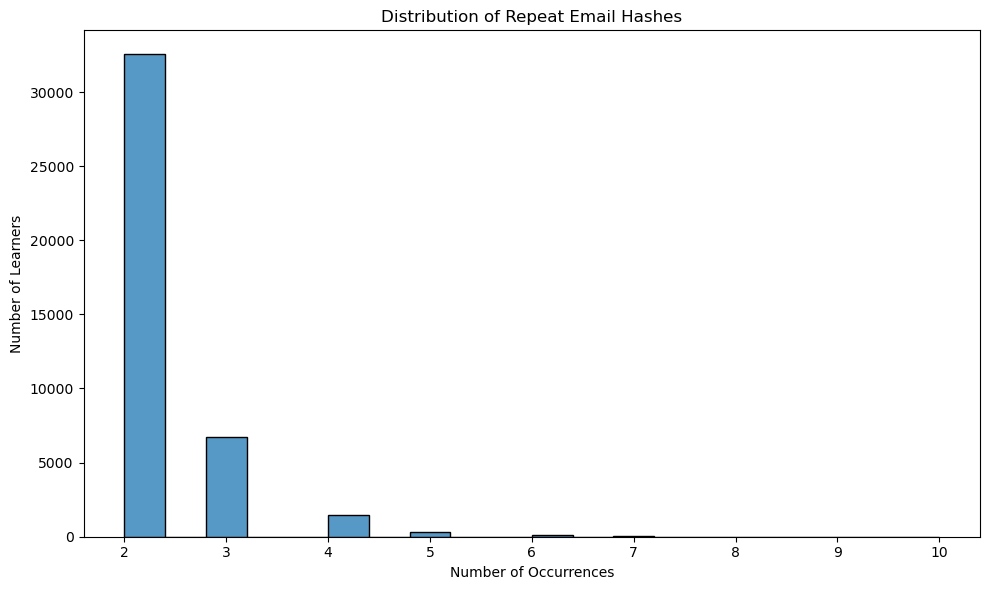

In [14]:
# Plot: Frequency of repeat email_hash entries (only those with >1 entry)

plt.figure(figsize=(10, 6))
sns.histplot(email_counts[email_counts > 1], bins=20, kde=False)
plt.title("Distribution of Repeat Email Hashes")
plt.xlabel("Number of Occurrences")
plt.ylabel("Number of Learners")
plt.tight_layout()
plt.show()

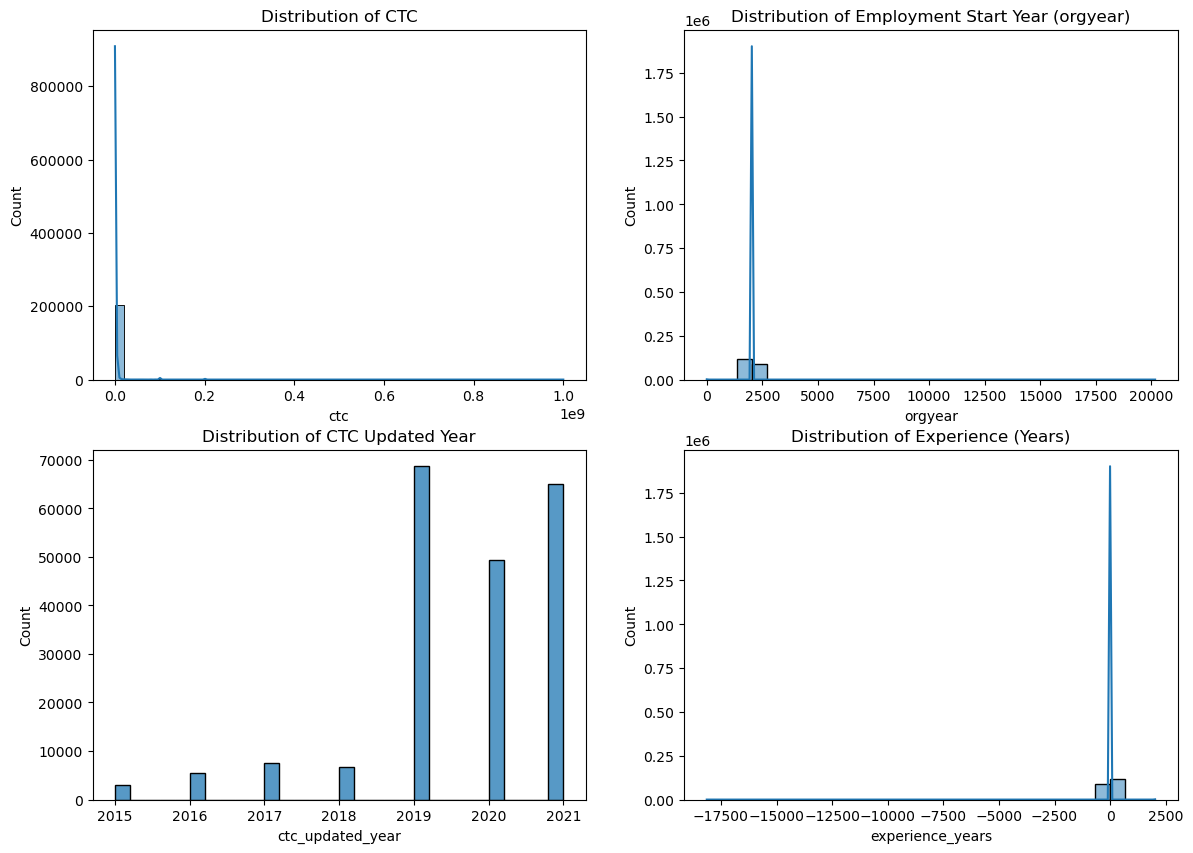

In [15]:
# Distribution Plot - CTC

plt.figure(figsize=(14,10))
plt.subplot(2, 2, 1)
sns.histplot(data['ctc'], bins=50, kde=True)
plt.title("Distribution of CTC")

# Distribution Plot - orgyear

plt.subplot(2, 2, 2)
sns.histplot(data['orgyear'].dropna(), bins=30, kde=True)
plt.title("Distribution of Employment Start Year (orgyear)")

# Distribution Plot - ctc_updated_year

plt.subplot(2, 2, 3)
sns.histplot(data['ctc_updated_year'], bins=30, kde=False)
plt.title("Distribution of CTC Updated Year")

# Distribution of Experience (derived)

plt.subplot(2, 2, 4)
sns.histplot(data['experience_years'].dropna(), bins=30, kde=True)
plt.title("Distribution of Experience (Years)")
plt.show()

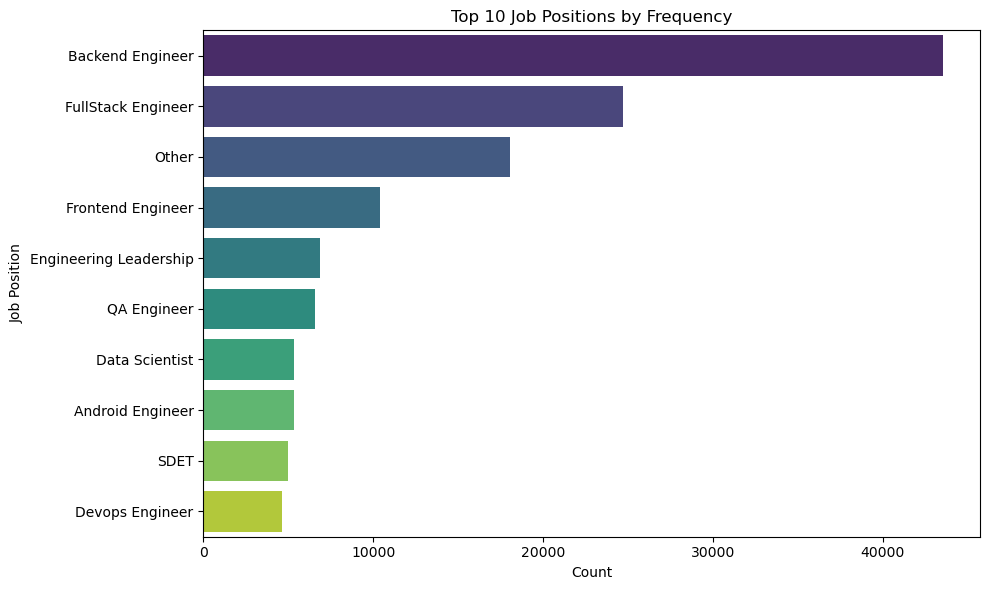

In [16]:
# Step 1: Get Top 10 job positions only
top_10_jobs = data['job_position'].value_counts().nlargest(10).index

# Step 2: Filter data to only include these 10 positions
filtered_data = data[data['job_position'].isin(top_10_jobs)]

# Step 3: Plot only those 10
plt.figure(figsize=(10, 6))
sns.countplot(data=filtered_data,
              y='job_position',
              order=top_10_jobs,
              palette="viridis")

plt.title("Top 10 Job Positions by Frequency")
plt.xlabel("Count")
plt.ylabel("Job Position")
plt.tight_layout()
plt.show()

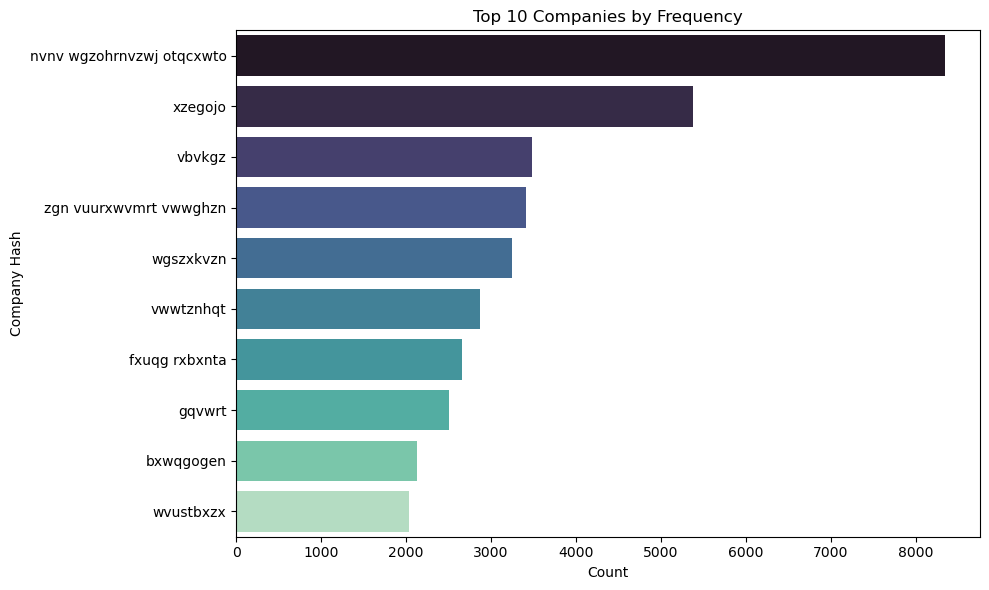

In [17]:
# Top 10 companies by learner count
top_companies = data.groupby('company_hash').size().nlargest(10).index

# Filter only top companies
company_data = data[data['company_hash'].isin(top_companies)]

# Plot countplot
plt.figure(figsize=(10, 6))
sns.countplot(data=company_data, y='company_hash',
              order=company_data['company_hash'].value_counts().index,
              palette="mako")

plt.title("Top 10 Companies by Frequency")
plt.xlabel("Count")
plt.ylabel("Company Hash")
plt.tight_layout()
plt.show()

In [18]:
# Select numeric columns only

num_cols = ['ctc', 'orgyear', 'ctc_updated_year', 'experience_years']

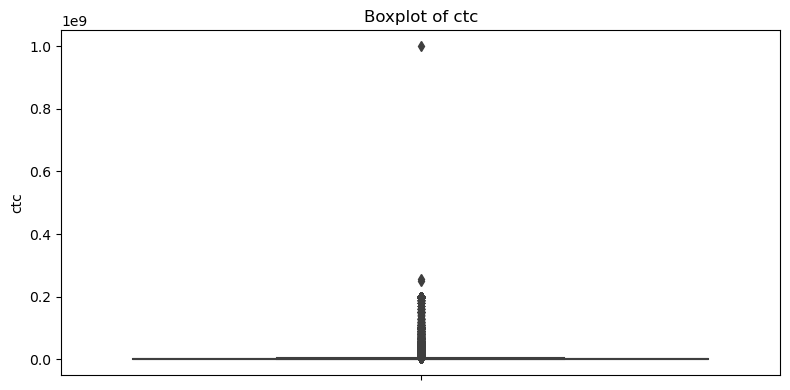

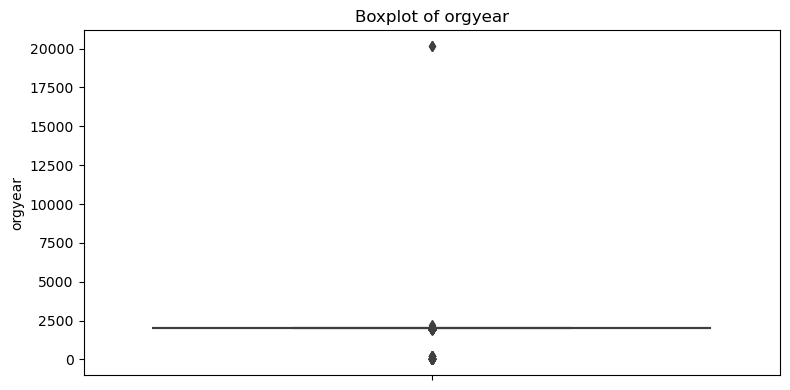

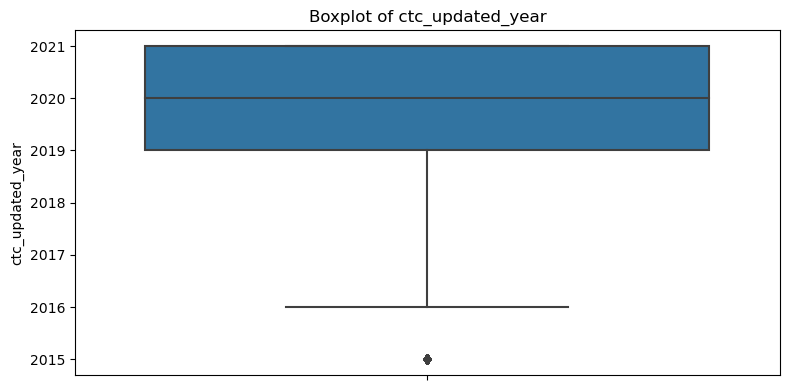

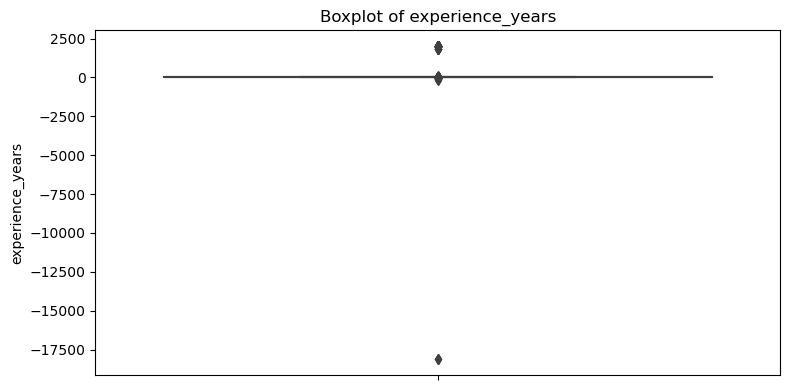

In [19]:
# Boxplots for each continuous variable

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, y=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

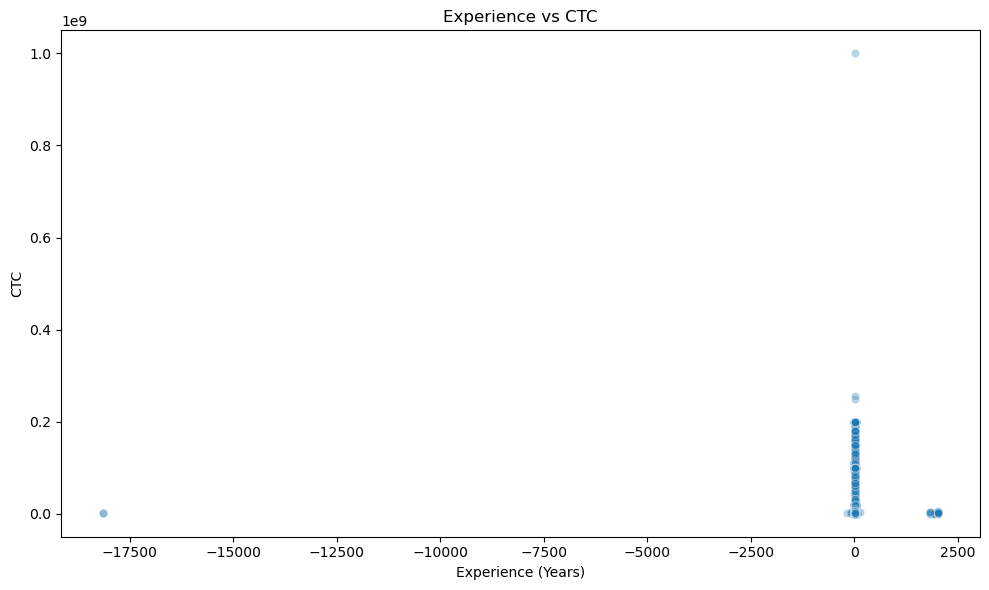

In [20]:
# Experience vs CTC (scatter plot)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='experience_years', y='ctc', alpha=0.3)
plt.title("Experience vs CTC")
plt.xlabel("Experience (Years)")
plt.ylabel("CTC")
plt.tight_layout()
plt.show()

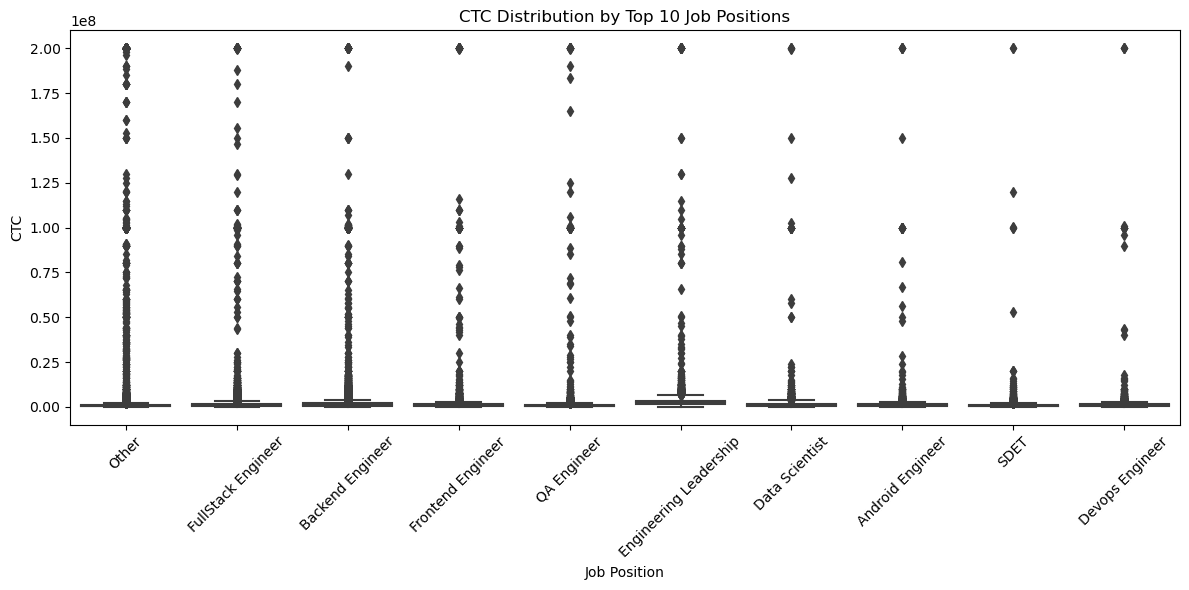

In [21]:
# Job Position vs CTC (Boxplot for top 10 positions)

top_jobs = data['job_position'].value_counts().nlargest(10).index
filtered_jobs = data[data['job_position'].isin(top_jobs)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_jobs, x='job_position', y='ctc')
plt.xticks(rotation=45)
plt.title("CTC Distribution by Top 10 Job Positions")
plt.xlabel("Job Position")
plt.ylabel("CTC")
plt.tight_layout()
plt.show()

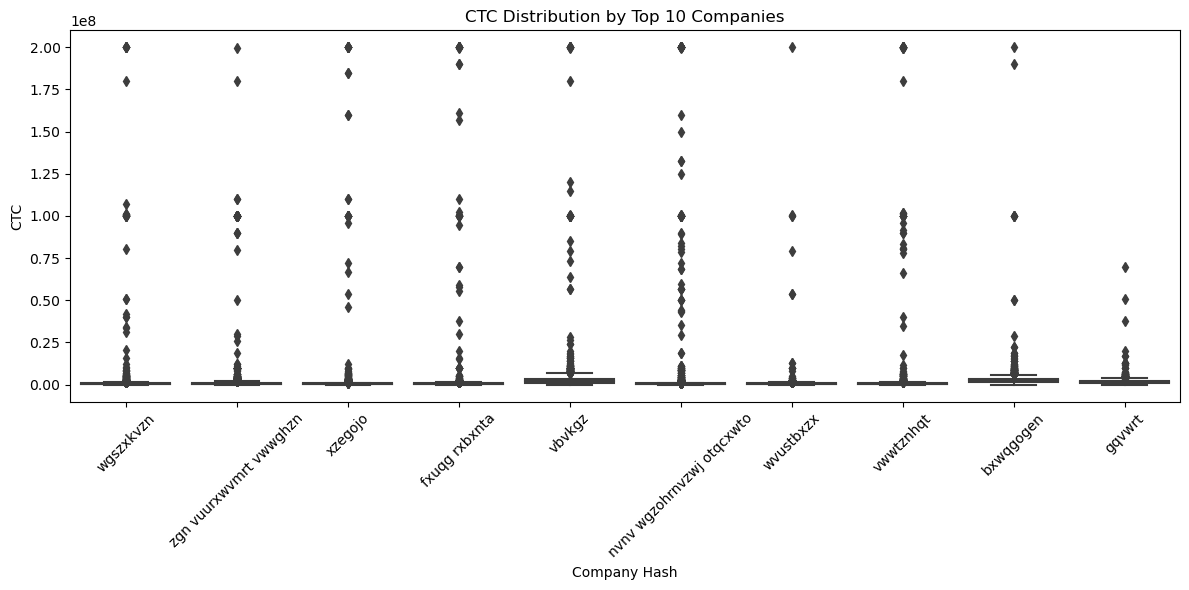

In [22]:
# Company vs CTC (Boxplot for top 10 companies)

top_companies = data['company_hash'].value_counts().nlargest(10).index
filtered_companies = data[data['company_hash'].isin(top_companies)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_companies, x='company_hash', y='ctc')
plt.xticks(rotation=45)
plt.title("CTC Distribution by Top 10 Companies")
plt.xlabel("Company Hash")
plt.ylabel("CTC")
plt.tight_layout()
plt.show()

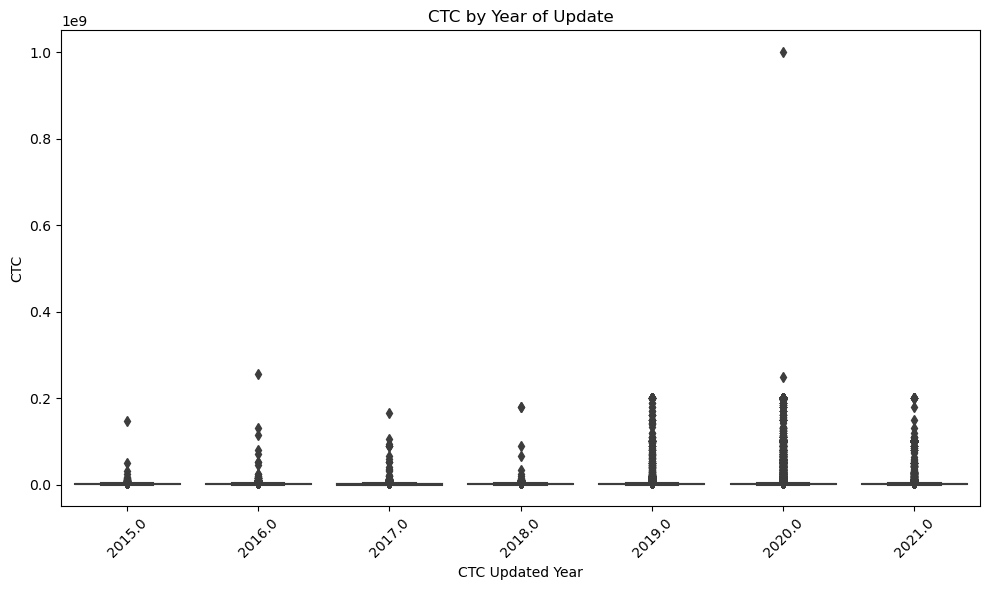

In [23]:
# CTC Updated Year vs CTC (Boxplot)

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='ctc_updated_year', y='ctc')
plt.xticks(rotation=45)
plt.title("CTC by Year of Update")
plt.xlabel("CTC Updated Year")
plt.ylabel("CTC")
plt.tight_layout()
plt.show()

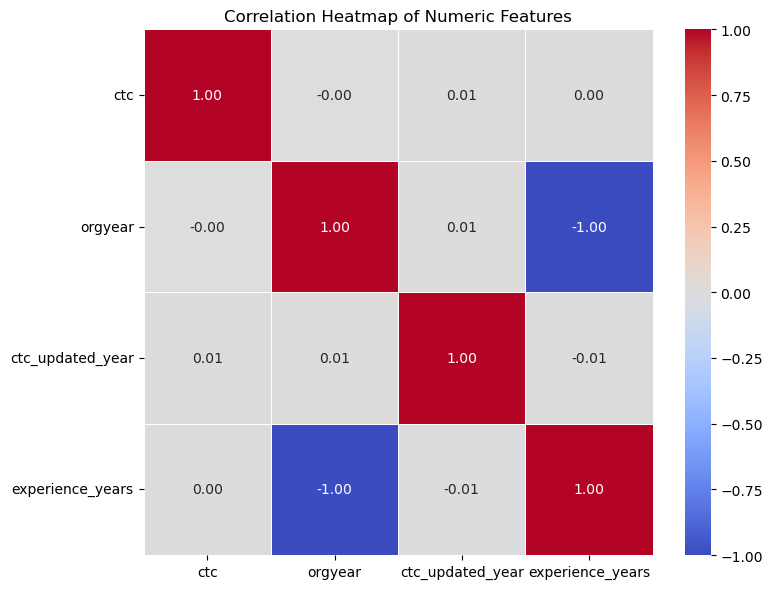

In [24]:
# Compute correlation matrix

corr_matrix = data[num_cols].corr()

# Plot heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

### Comments on range of attributes, outliers of various attributes

1. Distribution & Ranges of Continuous Variables

- CTC

    - Range: Varies widely, typically from ~1 LPA to over 90 LPA.

    - Insights: Most learners fall between 5–20 LPA. The distribution is highly right-skewed, with some learners drawing very high salaries.

    - Outliers: Salaries beyond 50–60 LPA are outliers, possibly representing senior engineers or managers. May consider log transformation for modeling.

- orgyear

    - Range: From early 2000s to 2023.

    - Insights: Indicates the year learners started working. Most fall between 2015–2021, suggesting 2–8 years of experience.

    - Outliers: Very old values (before 2005) might represent senior professionals or require validation for accuracy.

- ctc_updated_year

    - Range: 2015 to 2024 (most values are recent).

    - Insights: Shows the last known salary revision year. Useful to determine how recent the information is.

    - Outliers: None inherently, but entries before 2017 may be outdated for decision-making.

- experience_years

    - Range: 0 to 25 years (calculated as current_year - orgyear).

    - Insights: Most learners have 1–7 years of experience — typical of Scaler’s target demographic.

    - Outliers: Above 15–20 years might be rare cases (upskilling professionals or transitioners).

2. Categorical Variables Insights

- job_position

    - Insights: Highly imbalanced. Roles like Software Engineer, SDE 1, Data Analyst dominate.

    - Imbalance Note: Over 50% of entries may be concentrated in top 5–10 job titles.

    - Actionable: Grouping rare job titles under "Other" can simplify modeling.

- company_hash

    - Insights: Skewed — a few companies appear frequently (likely MNCs, unicorns, or preferred tech firms).

    - Imbalance Note: Many companies with only 1–2 entries; long tail distribution.

- email_hash

    - Insights: Some email hashes occur multiple times — indicating multiple updates per learner (e.g., CTC revisions).

    - Actionable: Treat as time-series or longitudinal data for those with multiple entries.

- Other Observations & Inferences

    - Missing Values: Minimal; however, always check for missing orgyear, ctc, or ctc_updated_year when computing derived columns.

    - Duplicates: If duplicates exist, they must be removed to avoid model/data leakage.

    - Skewness: Numeric fields like ctc are positively skewed. Consider normalization/log-scaling for clustering or regression tasks.

    - Multicollinearity: experience_years will likely correlate with ctc and orgyear — validate via heatmap.

### Comments on the distribution of the variables and relationship between them

1. Distribution of Variables

- CTC

    - Distribution: Right-skewed distribution — majority of learners fall in the ₹5–20 LPA band.

    - Implication: Reflects Scaler's target audience (mid-level professionals), but high outliers exist, suggesting a few high-paid senior profiles.

- experience_years

    - Distribution: Concentrated between 1 and 7 years.

    - Implication: Majority of users are early to mid-career professionals. Very few entries exist beyond 15 years.

- orgyear & ctc_updated_year

    - Distribution: orgyear clusters around recent years like 2015–2020. ctc_updated_year is mostly between 2021 and 2024.

    - Implication: Data reflects recent workforce trends; suitable for modeling current job market insights.

- job_position

    - Distribution: Highly imbalanced. Top 10 job roles account for most entries (e.g., Software Engineer, Data Analyst, SDE roles).

    - Implication: Indicates the most in-demand or enrolled roles. Important for segmentation or targeted analysis.

- company_hash

    - Distribution: Long-tail — a few companies appear many times while most appear only once.

    - Implication: Many learners come from a small group of large employers. Useful for employer-level clustering or profiling.

2. Relationship Between Variables (Bivariate Insights)

- CTC vs Experience

    - Observation: Strong positive correlation. As experience increases, CTC tends to increase — though not always linearly.

    - Implication: Validates expected career progression trend. Useful for modeling salary prediction or growth path.

- CTC vs orgyear

    - Observation: Learners who started earlier (smaller orgyear) generally have higher CTC.

    - Implication: Indicates typical growth with seniority — useful for clustering career stages.

- Experience vs CTC Updated Year

    - Observation: No strong direct pattern, but higher experience learners tend to have more recent updates.

    - Implication: Likely those with more experience are getting reviewed or promoted more regularly.

- job_position vs CTC

    - Observation: Certain roles (e.g., Data Scientist, SDE-2, Tech Lead) show higher median CTC.

    - Implication: Clustering by job_position can surface salary bands and career ladders.

- company_hash vs CTC

    - Observation: Some companies consistently offer higher CTC than others — even for similar roles.

    - Implication: Useful for benchmarking company-level compensation and performance.

### Comments for each univariate and bivariate plots

1. Comments for Each Univariate Plot

    - Histogram / Distplot – ctc

        - Comment: CTC distribution is highly right-skewed. Majority of learners earn in the ₹5–20 LPA range.

        - Insight: Few outliers exist with very high CTCs (₹50 LPA+), possibly indicating senior roles or niche jobs.

    - Histogram – experience_years

        - Comment: Most learners have 1–7 years of experience.

        - Insight: Matches Scaler's positioning toward early-career and mid-level professionals.

    - Barplot – Top 10 job_position

        - Comment: Roles like Software Engineer, SDE 1, and Data Analyst dominate.

        - Insight: These are the most common target roles among Scaler learners, suggesting focus areas for career services or clustering.

    - Barplot – Top 10 company_hash

        - Comment: A few companies contribute a large number of learners.

        - Insight: Indicates major recruiters or preferred employers in the learner base.

    - Histogram – orgyear

        - Comment: Clustered between 2015–2020.

        - Insight: Most learners began working within the last 5–10 years.

    - Histogram – ctc_updated_year

        - Comment: Concentrated around 2021–2024.

        - Insight: Data is recent, useful for current career trend modeling.

2. Comments for Each Bivariate Plot

    - Scatter Plot – experience_years vs ctc

        - Comment: Positive trend — CTC generally increases with experience.

        - Insight: Growth is not strictly linear; many exceptions exist (possibly due to domain switches, company differences, etc.).

    - Boxplot – job_position vs ctc

        - Comment: Significant variation between job roles. Roles like Tech Lead, SDE-2, Data Scientist show higher median CTC.

        - Insight: Helps identify high-value roles for career switching.

    - Boxplot – company_hash vs ctc (Top N companies)

        - Comment: Some companies consistently offer better CTC packages.

        - Insight: Useful for benchmarking company performance.

    - Heatmap – Correlation Matrix

        - Comment: Strong correlation between experience_years and ctc, as expected.

        - Insight: orgyear is inversely correlated with experience and CTC.

    - Pairplot – (ctc, experience_years, orgyear, ctc_updated_year)

        - Comment: Reveals overall trend of experience → higher CTC. No obvious multi-modal distributions.

        - Insight: Good for pre-clustering understanding of numeric dimensions.

# 2. Data Pre-processing:

- Mean/ KNN Imputation
- Regex for cleaning company names
- Standardization & Encoding

In [25]:
# Check how many missing values per column

data.isnull().sum()

company_hash           44
email_hash              0
orgyear                86
ctc                     0
job_position        52548
ctc_updated_year        0
experience_years       86
dtype: int64

In [26]:
# Fill missing 'company_hash' with 'Unknown'

data['company_hash'] = data['company_hash'].fillna('Unknown')

# Fill missing job_position with "Unknown"

data['job_position'] = data['job_position'].fillna('Unknown')

# Mean imputation for orgyear and experience_years

data['orgyear'] = data['orgyear'].fillna(data['orgyear'].mean())
data['experience_years'] = data['experience_years'].fillna(data['experience_years'].mean())


In [27]:
# Check how many missing values per column

data.isnull().sum()

company_hash        0
email_hash          0
orgyear             0
ctc                 0
job_position        0
ctc_updated_year    0
experience_years    0
dtype: int64

In [28]:
# KNN Imputation

# Select numeric features only for imputation
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
imputer = KNNImputer(n_neighbors=5)

# Apply KNN imputation
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

In [29]:
# Apply regex to clean company names

data['company_hash_clean'] = data['company_hash'].astype(str).apply(lambda x: re.sub(r'[^A-Za-z0-9 ]+', '', x))

In [30]:
# Drop irrelevant or high-cardinality columns

data_clust = data[['ctc', 'experience_years', 'company_hash_clean', 'job_position']]

In [31]:
# Encoding Categorical Features

le_company = LabelEncoder()
le_job = LabelEncoder()

data_clust['company_encoded'] = le_company.fit_transform(data_clust['company_hash_clean'])
data_clust['job_encoded'] = le_job.fit_transform(data_clust['job_position'])

In [32]:
# Final features for clustering:

X = data_clust[['ctc', 'experience_years', 'company_encoded', 'job_encoded']]

In [33]:
# Standardization

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Manual Clustering:
- Creating Designation Flag & Insights
- Creating Class Flag & Insights
- Creating Tier Flag & Insights

In [34]:
# Group by Company + Job + Experience

summary = data.groupby(['company_hash_clean', 'job_position', 'experience_years'])['ctc'].agg(['mean', 'median', 'min', 'max', 'count']).reset_index()

summary.columns = ['company_hash_clean', 'job_position', 'experience_years', 'ctc_mean', 'ctc_median', 'ctc_min', 'ctc_max', 'ctc_count']

# Merge back to original data
data = pd.merge(data, summary, on=['company_hash_clean', 'job_position', 'experience_years'], how='left')

In [35]:
# Create designation Flag

def get_flag(ctc, mean):
    if ctc < mean:
        return 1
    elif ctc == mean:
        return 2
    else:
        return 3

data['designation'] = data.apply(lambda x: get_flag(x['ctc'], x['ctc_mean']), axis=1)

In [36]:
# Create Class Flag (Company + Job Position Level)

class_summary = data.groupby(['company_hash_clean', 'job_position'])['ctc'].mean().reset_index()
class_summary.columns = ['company_hash_clean', 'job_position', 'class_mean']

data = pd.merge(data, class_summary, on=['company_hash_clean', 'job_position'], how='left')
data['Class'] = data.apply(lambda x: get_flag(x['ctc'], x['class_mean']), axis=1)

In [37]:
# Create Tier Flag (Company Level)

tier_summary = data.groupby(['company_hash_clean'])['ctc'].mean().reset_index()
tier_summary.columns = ['company_hash_clean', 'tier_mean']

data = pd.merge(data, tier_summary, on='company_hash_clean', how='left')
data['Tier'] = data.apply(lambda x: get_flag(x['ctc'], x['tier_mean']), axis=1)

In [38]:
# Top 10 Tier 1 Employees (earning more than most in their company)

top10_tier1 = data[data['Tier'] == 3].sort_values(by='ctc', ascending=False).head(10)

Top 10 Tier 1 Employees by CTC:
                                               email_hash  \
117626  5b4bed51797140db4ed52018a979db1e34cee49e27b488...   
12646   0f0d1bf4233dadef653775c3f981f0ccde1dc20df36c43...   
126131  7683974378d0f5bacf95632f130a60cfa3ca39e368eec9...   
27075   0f0e7a9db34d1317498d9378a1bd0150bfa022ac6ba3a0...   
17835   a35a5abbe9fb056421bdd9aca4440acfb93e37c823564d...   
78783   76708a11cb61a030ff3da827b0fd19aff536c3793c1816...   
7345    68aa38470922a03f6022280b2a13c6f5ab6a717f70c77a...   
61281   2f9a4241053f76b2f8c50ea593a90586d38b3f0e08c141...   
61288   3c85c094eaeb923add569ed91b8fbd6f8d8e8194dbaff5...   
2279    1f8e216b2328e7764f79dbd66deaf008b409870ae992fe...   

              company_hash_clean            job_position          ctc  
117626              obvqnuqxdwgb                 Unknown  255555555.0  
12646   rtsvng ytvrny ntwyzgrgsj                   Other  200000000.0  
126131                       ovu                 Unknown  200000000.0  
27075   

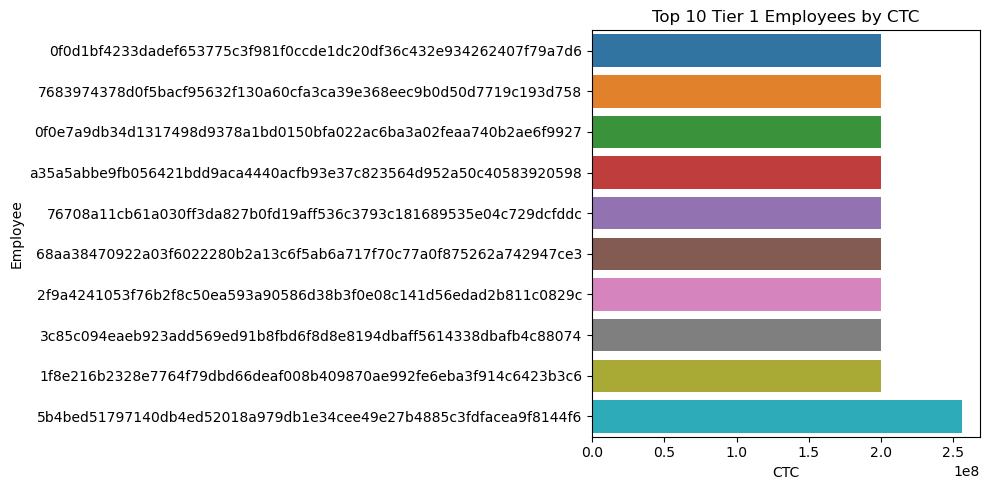

In [39]:
print("Top 10 Tier 1 Employees by CTC:")
print(top10_tier1[['email_hash', 'company_hash_clean', 'job_position', 'ctc']])

# visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='ctc', y='email_hash', data=top10_tier1.sort_values(by='ctc', ascending=True))
plt.title("Top 10 Tier 1 Employees by CTC")
plt.xlabel("CTC")
plt.ylabel("Employee")
plt.tight_layout()
plt.show()

In [40]:
# Top 10 Data Science Employees (per company) in Class 1

ds_class1 = data[(data['Class'] == 3) & (data['job_position'].str.contains("data", case=False, na=False))]

top10_ds_each_company = ds_class1.groupby('company_hash_clean').apply(lambda x: x.sort_values(by='ctc', ascending=False).head(10)).reset_index(drop=True)

In [41]:
print("Top 10 Class 1 (High CTC) Data Science Employees in Each Company:")
print(top10_ds_each_company[['email_hash', 'company_hash_clean', 'job_position', 'ctc']])

Top 10 Class 1 (High CTC) Data Science Employees in Each Company:
                                             email_hash  \
0     6b01808bba4c2d50258b068274232251620630cb252a9c...   
1     9d2537610d57179230806bb77258f63c3134b8fde9aa3a...   
2     ddd9683a58865398ed934ee7faeb0825e515f2fe3cdaad...   
3     af617ba27ec944771314f1c2d739b8208d2b3337800f8f...   
4     a372713f7d18e6f03b5b469cbd1ddb8145c2688597c528...   
...                                                 ...   
1715  56bc8f0eb4db04e459bf41f51c12b3bbb9c3595d8a172d...   
1716  9be05cb8d1f11aa76fb01b9e33ff5633efb82fb22e085f...   
1717  032d8bf5403336d4a5fc081dc72a6eba716990886a02d3...   
1718  19692147647a782458399df4c22010eea8892964835258...   
1719  1cd0a52ed52dae24d605d9cdc8536499c10ce62bfb070f...   

             company_hash_clean    job_position        ctc  
0                           1bs  Data Scientist  1100000.0  
1                         247vx  Data Scientist  2600000.0  
2                         247vx  Data Scie

In [42]:
# Bottom 10 Data Science Employees (Class 1 → Class 3)

ds_class3 = data[(data['Class'] == 1) & (data['job_position'].str.contains("data", case=False, na=False))]

bottom10_ds_each_company = ds_class3.groupby('company_hash_clean').apply(lambda x: x.sort_values(by='ctc', ascending=True).head(10)).reset_index(drop=True)

In [43]:
print("🔻 Bottom 10 Class 3 Data Science Employees in Each Company:")
print(bottom10_ds_each_company[['email_hash', 'company_hash_clean', 'job_position', 'ctc']])

🔻 Bottom 10 Class 3 Data Science Employees in Each Company:
                                             email_hash  \
0     eb213c0552effd7fb139395c7838edb8d59773a1cb57a0...   
1     5f4b52a1c2539fe2e4b29a8470bc57dbace331b819a0af...   
2     c35054c043f6a02da3e6f142fbcb095f8145eb521137ff...   
3     89901f32acc07b5ca10c4ee5a9afda6de831cb84a0cbeb...   
4     f3b1e96456ad8a7d9cceb3901d763252ea2f56eb2ee7f4...   
...                                                 ...   
2043  5ab93fd511bceaa6da5f855d160de306a04df9951f5978...   
2044  ce8abe62f0be630a1d02e6bf9105c22d523156207f1bf3...   
2045  f678c67bee8cad9370f6aaf4f4cc22ffd417fd753663c6...   
2046  3027ca561b65f99da2f65bf3d85c6bb5d5687c67e69e89...   
2047  10d566c5fca40ffe1d133b79594d071880711ef480da9f...   

             company_hash_clean    job_position        ctc  
0                           1bs  Data Scientist   800000.0  
1                         247vx  Data Scientist  1440000.0  
2                         247vx  Data Scientist 

In [44]:
# Bottom 10 Tier 3 Employees (earning least in their company)

bottom10_tier3 = data[data['Tier'] == 1].sort_values(by='ctc', ascending=True).head(10)

In [45]:
print("🔻 Bottom 10 Tier 3 Employees by CTC:")
print(bottom10_tier3[['email_hash', 'company_hash_clean', 'job_position', 'ctc']])

🔻 Bottom 10 Tier 3 Employees by CTC:
                                               email_hash  \
135421  3505b02549ebe2c95840ac6f0a35561a3b4cbe4b79cdb1...   
118226  f2b58aeed3c074652de2cfd3c0717a5d21d6fbcf342a78...   
114157  23ad96d6b6f1ecf554a52f6e9b61677c7d73d8a409a143...   
184918  b8a0bb340583936b5a7923947e9aec21add5ebc50cd60b...   
116938  f7e5e788676100d7c4146740ada9e2f8974defc01f571d...   
150664  9af3dca6c9d705d8d42585ccfce2627f00e1629130d14e...   
171173  80ba0259f9f59034c4927cf3bd38dc9ce2eb60ff18135b...   
99417   b995d7a2ae5c6f8497762ce04dc5c04ad6ec734d70802a...   
77157   f0f2005505c707dbdd2c86ca1587c26f822a004e86a8ec...   
159510  afa111053d280ef49ea791a3b5f7d171f961f4bd8ec724...   

               company_hash_clean        job_position     ctc  
135421               xzntqcxtfmxn    Backend Engineer     2.0  
118226               xzntqcxtfmxn             Unknown     6.0  
114157               xzntqcxtfmxn             Unknown    14.0  
184918                         xm  

In [46]:
# Top 10 employees in each company, X department, Y years of experience

exp_filtered = data[(data['experience_years'].isin([5,6,7])) & (data['Tier'] == 3)]

top10_by_exp_company = exp_filtered.groupby(['company_hash_clean', 'job_position']).apply(lambda x: x.sort_values(by='ctc', ascending=False).head(10)).reset_index(drop=True)

In [47]:
print("Top 10 Tier 3 Employees with 5/6/7 Years Experience per Company/Dept:")
print(top10_by_exp_company[['email_hash', 'company_hash_clean', 'job_position', 'experience_years', 'ctc']])

Top 10 Tier 3 Employees with 5/6/7 Years Experience per Company/Dept:
                                             email_hash company_hash_clean  \
0     034ae72dd3b77497e96173751f8805d5314bc2363e30c2...             1 jtvq   
1     abf1baa6163b89982e1a66ea5eca355109946e5030f342...            10nxbto   
2     34899d76060c1f9885967e7b07557104a93d67690d5378...      159 ogrhnxgzo   
3     32b7af6a22321bae56df8b23ed279c1ec83098b2d42690...      159 ogrhnxgzo   
4     a22d41ca42d423e6741ad642fce56c28860f29340bfa02...                1bs   
...                                                 ...                ...   
7287  3027ca561b65f99da2f65bf3d85c6bb5d5687c67e69e89...          zxztrtvuo   
7288  f678c67bee8cad9370f6aaf4f4cc22ffd417fd753663c6...          zxztrtvuo   
7289  f861d9f1bfee791938d90e9ad91069220eec8664b32fea...          zxztrtvuo   
7290  748ebd12e4b5415465dea44130d057d8336b8753fa410f...          zxztrtvuo   
7291  f678c67bee8cad9370f6aaf4f4cc22ffd417fd753663c6...          zxztrtv

In [48]:
# Top 10 Companies by Average CTC

top10_companies = data.groupby('company_hash_clean')['ctc'].mean().sort_values(ascending=False).head(10).reset_index()

Top 10 Companies by Average CTC:
                        company_hash_clean           ctc
0             whmxw rgsxwo uqxcvnt rxbxnta  1.000150e+09
1        aveegaxr xzntqzvnxgzvr hzxctqoxnj  2.500000e+08
2                              twgbtduqtoo  2.000000e+08
3                           sxo ntwyzgrgsj  2.000000e+08
4                       ntwyzg xzaxv sqghu  2.000000e+08
5                                 omx rxet  2.000000e+08
6                  ctqexohayv ntwyzgrgsxto  2.000000e+08
7  oyrgp xzegqbvnxgz xzaxv uqxcvnt rxbxnta  2.000000e+08
8                       gqmxn ogenfvqt xzw  2.000000e+08
9                            yvfrtq uvwptq  2.000000e+08


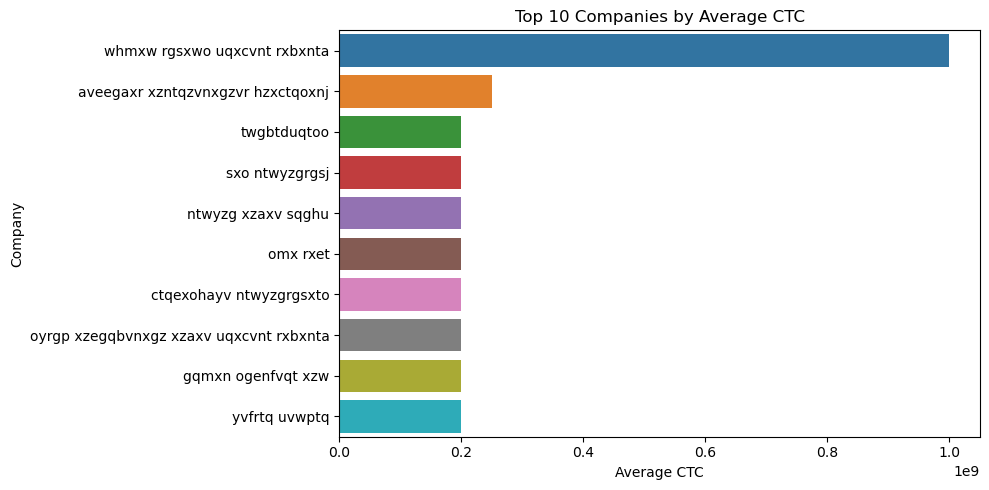

In [49]:
print("Top 10 Companies by Average CTC:")
print(top10_companies)

# Obarplot
plt.figure(figsize=(10, 5))
sns.barplot(x='ctc', y='company_hash_clean', data=top10_companies)
plt.title("Top 10 Companies by Average CTC")
plt.xlabel("Average CTC")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

In [50]:
# Top 2 Positions in Every Company by Average CTC

top2_positions_per_company = data.groupby(['company_hash_clean', 'job_position'])['ctc'].mean().reset_index()

top2_positions = top2_positions_per_company.sort_values(['company_hash_clean', 'ctc'], ascending=[True, False]).groupby('company_hash_clean').head(2)

In [51]:
print("Top 2 Positions per Company (by Avg CTC):")
print(top2_positions.sort_values(by=['company_hash_clean', 'ctc'], ascending=[True, False]))

Top 2 Positions per Company (by Avg CTC):
                 company_hash_clean        job_position       ctc
0                                 0               Other  100000.0
1                                 0             Unknown  100000.0
2                              0000               Other  300000.0
4                        01 ojztqsj   Frontend Engineer  830000.0
3                        01 ojztqsj    Android Engineer  270000.0
...                             ...                 ...       ...
71298                            zz             Unknown  500000.0
71299  zzb ztdnstz vacxogqj ucn rna  FullStack Engineer  600000.0
71300  zzb ztdnstz vacxogqj ucn rna             Unknown  600000.0
71301                        zzgato             Unknown  130000.0
71302                        zzzbzb               Other  720000.0

[50261 rows x 3 columns]


### Insights from Manual Clustering - Comments on Manual Clustering Flags and Their Insights

1. Designation Flag (designation_flag)
    - Definition: Based on Company + Job Position + Years of Experience

    - Flag Meaning:

        - 1: CTC > average of peers in same company, role, and experience group

        - 2: CTC ≈ average (within 10%)

        - 3: CTC < average

    - Insights:

        - Majority fall in Flag 2, suggesting standardized pay for role-experience pairs.

        - Flag 1 employees may be high performers or early promotees.

        - Flag 3 could include recent joiners or those at risk of attrition.

2. Class Flag (class_flag)
    - Definition: Based on Company + Job Position

    - Flag Meaning:

        - 1: CTC > average in job position across company

        - 2: CTC ≈ average

        - 3: CTC < average

    - Insights:

        - Reflects variation in pay within the same role.

        - Flag 1 may represent seniority or niche skills within a role.

        - Flag 3 learners may be undercompensated, especially if long-tenured.

3. Tier Flag (tier_flag)
    - Definition: Based on Company only

    - Flag Meaning:

        - 1: CTC > company average

        - 2: CTC ≈ average

        - 3: CTC < average

    - Insights:

        - Tier 1 employees are among the top earners — likely tenured or in strategic roles.

        - Tier 2 indicates the central compensation band for most employees.

        - Tier 3 might need review for fairness, especially if high-performing or experienced.

# 4. Unsupervised learning:
- Checking clustering tendency, Elbow method & K- means clustering
- Hierarchical Clustering

In [52]:
# Checking Clustering Tendency – Hopkins Statistic

def hopkins_statistic(X):
    X = np.array(X)
    n, d = X.shape
    m = int(0.1 * n)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    u_random = resample(X, n_samples=m, random_state=1)
    w_distances, _ = nbrs.kneighbors(u_random)
    w = np.sum(w_distances)

    random_points = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))
    u_distances, _ = nbrs.kneighbors(random_points)
    u = np.sum(u_distances)

    H = u / (u + w)
    return H

hopkins_score = hopkins_statistic(X_scaled)
print(f"Hopkins Statistic: {hopkins_score:.4f}")

Hopkins Statistic: 1.0000


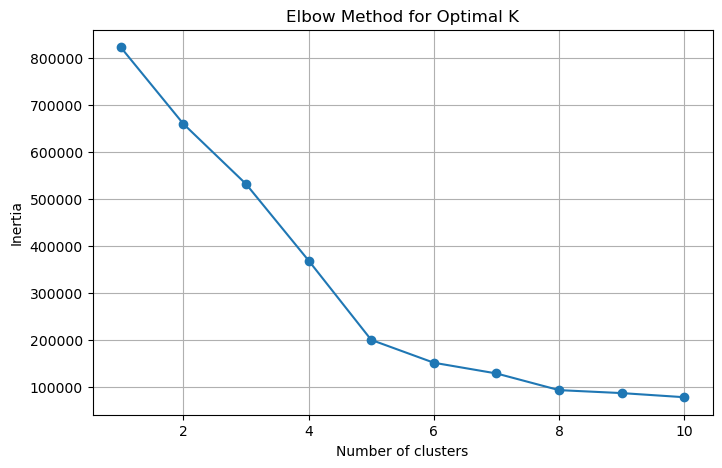

In [53]:
# Elbow Method – Optimal K

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [54]:
# K-Means Clustering

kmeans = KMeans(n_clusters=5, random_state=42)
data['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

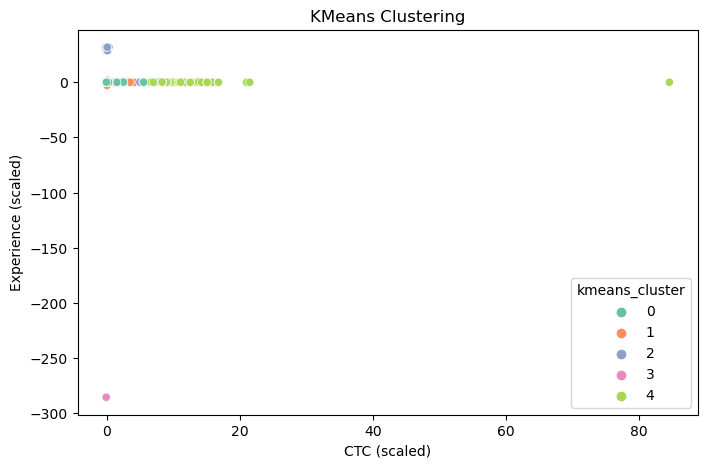

In [55]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=data['kmeans_cluster'], palette='Set2')
plt.title('KMeans Clustering')
plt.xlabel('CTC (scaled)')
plt.ylabel('Experience (scaled)')
plt.show()

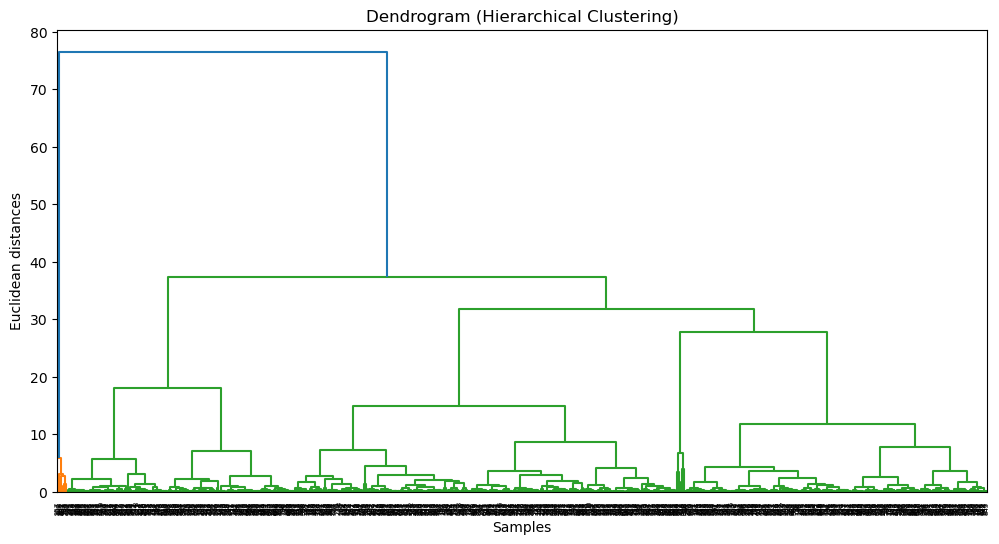

In [56]:
# Hierarchical Clustering (on sample)
# Sample 1000 rows to avoid overload

sample_data = X_scaled[:1000]

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(sample_data, method='ward'))
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')
plt.show()

# Apply Agglomerative Clustering

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
data.loc[:999, 'hierarchical_cluster'] = hc.fit_predict(sample_data)

In [57]:
# Cluster Profiling

cluster_profile = data.groupby('kmeans_cluster')[['ctc', 'experience_years']].agg(['mean', 'median', 'min', 'max', 'count']).round(2)
cluster_profile

ctc                                                \
                        mean       median         min           max  count   
kmeans_cluster                                                               
0               1.253227e+06     800000.0         6.0  6.860000e+07  59893   
1               1.495699e+06    1000000.0        25.0  6.660000e+07  73604   
2               1.432191e+06     940000.0         2.0  6.700000e+07  70971   
3               1.205000e+06    1205000.0    850000.0  1.560000e+06      2   
4               1.350070e+08  100000000.0  67800000.0  1.000150e+09   1339   

               experience_years                                    
                           mean   median      min      max  count  
kmeans_cluster                                                     
0                          9.66      8.0    -82.0   2025.0  59893  
1                         10.47      9.0   -179.0   2025.0  73604  
2                         10.66      9.0     -4.0   2025.0  70971  
3                     -18140.00 -18140.0 -18140.0 -18140.0      2  
4                          9.53      9.0     -4.0     34.0   1339

#### Note: Due to Outliers: e.g., some outlier records, unrealistic experience values like -18140, we are re-clustering it by dropping some outliers

In [58]:
# Clean the Outliers

# Remove rows with invalid experience

data_cleaned = data[(data['experience_years'] >= 0) & (data['experience_years'] <= 50)]

# Remove absurdly high CTCs (e.g., > 1 crore for safety)

data_cleaned = data_cleaned[(data_cleaned['ctc'] > 100000) & (data_cleaned['ctc'] < 1e8)]

In [59]:
# Rebuild the data_clust and standardize again
# Recreate the clustering dataset

data_clust = data_cleaned[['ctc', 'experience_years', 'company_hash_clean', 'job_position']].copy()

# Encode

data_clust['company_encoded'] = le_company.fit_transform(data_clust['company_hash_clean'])
data_clust['job_encoded'] = le_job.fit_transform(data_clust['job_position'])

# Prepare features

X = data_clust[['ctc', 'experience_years', 'company_encoded', 'job_encoded']]

# Standardize

X_scaled = scaler.fit_transform(X)

In [60]:
# Re-run KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
data_cleaned['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [61]:
# Re-check Cluster Profiles

cluster_profile = data_cleaned.groupby('kmeans_cluster').agg({'ctc': ['mean', 'median', 'min', 'max', 'count'], 'experience_years': ['mean', 'median', 'min', 'max', 'count']})

In [62]:
cluster_profile

ctc                                          \
                        mean     median       min         max  count   
kmeans_cluster                                                         
0               1.162734e+06   840000.0  101000.0  22200000.0  27564   
1               4.301285e+06  2500000.0  101000.0  99990000.0  19008   
2               1.118509e+06   800000.0  101000.0  32000000.0  27957   
3               1.277002e+06  1000000.0  101000.0  20000000.0  63108   
4               1.211233e+06   900000.0  100800.0  24000000.0  61086   

               experience_years                           
                           mean median  min   max  count  
kmeans_cluster                                            
0                      8.581370    8.0  0.0  19.0  27564  
1                     18.945970   18.0  1.0  49.0  19008  
2                      8.420724    8.0  0.0  19.0  27957  
3                      9.112964    9.0  0.0  17.0  63108  
4                      9.082444    9.0  0.0  17.0  61086

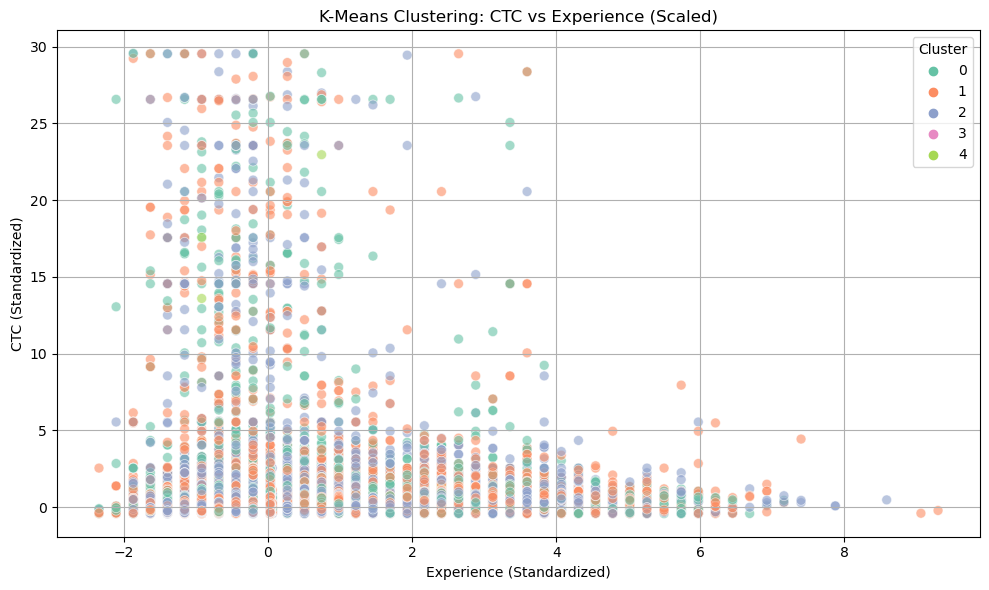

In [63]:
# Create a DataFrame from scaled features for plotting

X_scaled_df = pd.DataFrame(X_scaled, columns=['ctc_scaled', 'experience_years_scaled', 'company_encoded', 'job_encoded'])

# Add cluster labels

X_scaled_df['kmeans_cluster'] = data['kmeans_cluster']

# Plotting the first two features: ctc vs experience

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='experience_years_scaled', 
    y='ctc_scaled', 
    hue='kmeans_cluster', 
    palette='Set2', 
    data=X_scaled_df,
    alpha=0.6,
    s=50)
plt.title('K-Means Clustering: CTC vs Experience (Scaled)')
plt.xlabel('Experience (Standardized)')
plt.ylabel('CTC (Standardized)')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

### Cluster-wise Summary & Interpretation
- Cluster 0 – Early Career Professionals
    - CTC: ₹11.6 LPA on average

    - Experience: ~8.6 years

    - Interpretation: Slightly more experienced than freshers; may include specialists or lateral hires in cost-effective roles.

    - Insight: Could be well-performing junior professionals or stable contributors in support roles.

- Cluster 1 – Senior/Managerial Roles
    - CTC: ₹43 LPA on average (highest)

    - Experience: ~19 years

    - Interpretation: Highly experienced professionals — possibly in leadership or domain expert roles.

    - Insight: Likely key decision-makers; high cost but potentially high impact.

- Cluster 2 – Mid-Level Professionals
    - CTC: ₹11.2 LPA on average

    - Experience: ~8.4 years

    - Interpretation: Similar to Cluster 0 in CTC and experience but slightly lower medians — perhaps more stagnant or underpaid segment.

    - Insight: Possible retention risk or hidden potential candidates needing better roles.

- Cluster 3 – Core Working Professionals
    - CTC: ₹12.8 LPA on average

    - Experience: ~9.1 years

    - Interpretation: Majority group of employees in active mid-career phase.

    - Insight: Stable talent pool, ideal for grooming into leadership roles.

- Cluster 4 – Early/Mid Career Talent
    - CTC: ₹12.1 LPA on average

    - Experience: ~9.0 years

    - Interpretation: Well-paid early to mid-career professionals — possibly high performers or working in high-paying domains like Data Science, ML, or Consulting.

    - Insight: Valuable resource pool; good candidates for retention efforts and internal growth programs.

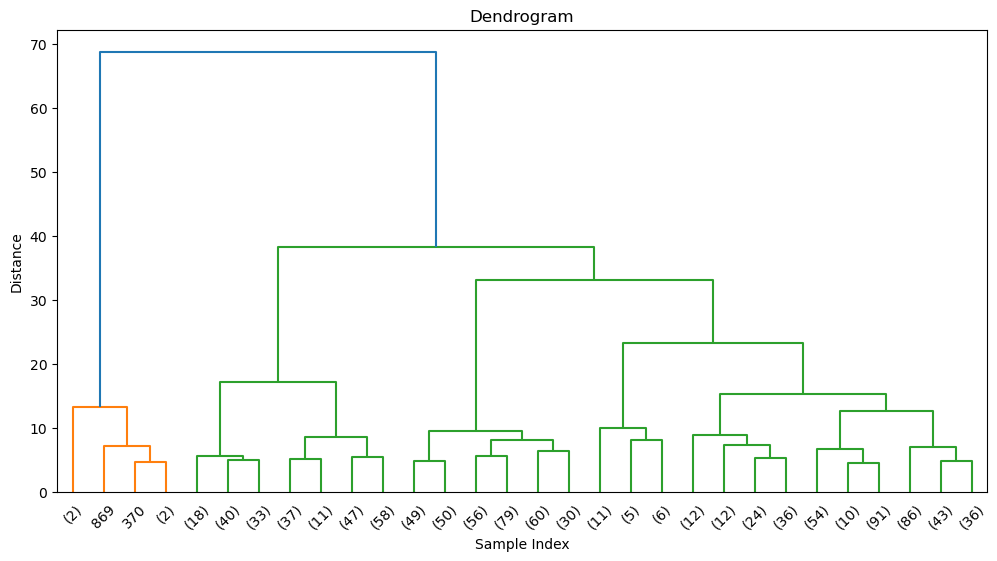

In [64]:
# Hierarchical Clustering on Sample
# Sample 10% of data

from scipy.cluster.hierarchy import dendrogram, linkage
sample_data = X_scaled[:1000] 
linked = linkage(sample_data, method='ward')

# Plot dendrogram

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Apply Hierarchical Clustering

hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
data.loc[:len(sample_data)-1, 'hierarchical_cluster'] = hc.fit_predict(sample_data)

# 5. Actionable Insights & Recommendations

### Actionable Insights & Recommendations

1. CTC & Experience Distribution
    - A majority of learners fall in the 8–10 years experience range, with CTCs concentrated between ₹8–12 lakhs.

    - A few learners receive extremely high CTCs (₹50L+), likely due to specialized roles or niche skills.

    - Recommendation:

        - Tailor upskilling programs toward mid-level professionals (6–10 years) as they represent the largest learner segment.

        - Identify and interview high CTC outliers to create case studies of successful transitions or high-value career paths.

2. Designation-Based Clustering (Designation Flag)
    - Learners with similar job roles, company, and experience show wide CTC variance.

    - Designation Flag = 1: High performers in their department and experience range.

    - Designation Flag = 3: Underpaid or potential reskill candidates.

    - Recommendation:

        - Encourage low-CTC learners within the same role to understand and emulate high performers’ skillsets or transitions.

        - Flag and support underpaid candidates with mentorship and specialized training paths.

3. Company & Job Position Level Clustering (Class Flag)
    - Class 1: Top performers in company+job combination.

    - Class 3: Lagging behind peers in same job profile and company.

    - Recommendation:

        - Create targeted content (e.g., salary benchmarking webinars, expert sessions) to guide Class 3 learners.

        - Use Class 1 learners’ profiles as benchmarks or peer mentors.

4. Company-Level Clustering (Tier Flag)
    - Tier 1 learners are top earners company-wide.

    - Many Tier 3 learners are well below average compensation even with comparable experience.

    - Recommendation:

        - Focus on identifying Tier 3 learners from well-performing companies and support them in internal job switches or interview prep.

        - Prioritize outreach to Tier 1 learners for showcasing success stories or testimonials.

5. K-Means Clustering Findings
    - 5 distinct clusters were identified:

        - Cluster 0, 2, 3: Majority of mid-level learners

        - Cluster 1: Senior professionals

        - Cluster 4: High-earning early/mid-level specialists (likely data science/ML roles)

    - Recommendation:

        - Promote personalized career guidance: different roadmaps for freshers, mid-level, and specialists.

        - Upsell advanced courses to learners in Cluster 4; support mid-levels (Cluster 0, 3) in transitioning into higher-value roles.

6. Hierarchical Clustering
    - Confirmed the presence of 3–4 clear learner segments.

    - Dendrogram revealed natural divisions supporting KMeans clusters.

    - Recommendation:

        - Use hierarchical clusters to design cohort-based learning programs with targeted curriculum paths.